# Loading the  Data

In [13]:
import pandas as pd

sensor = pd.read_csv("sensor_readings_train.csv")
system = pd.read_csv("system_states_train.csv")
actions = pd.read_csv("action_logs_train.csv")
rewards = pd.read_csv("reward_signals_train.csv")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Merge and Sort Data

In [14]:
df = sensor.merge(system, on="timestamp").merge(actions, on="timestamp").merge(rewards, on="timestamp")
df = df.sort_values('timestamp').reset_index(drop=True)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Encoding All the Categorical Columns

In [16]:
from sklearn.preprocessing import LabelEncoder

# Find non-numeric columns
cat_cols = df.select_dtypes(include=['object']).columns.drop('timestamp')
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Building RL Tuples (state, action, reward, next_state)

In [17]:
# State features = all but timestamp, action_taken, reward
state_features = [col for col in df.columns if col not in ['timestamp', 'action_taken', 'reward']]
action_feature = "action_taken"
reward_feature = "reward"

transitions = []
for i in range(len(df) - 1):
    s = df.loc[i, state_features].values.astype(float)
    a = df.loc[i, action_feature]
    r = df.loc[i, reward_feature]
    s_next = df.loc[i+1, state_features].values.astype(float)
    transitions.append((s, a, r, s_next))
print("Number of transitions:", len(transitions))


Number of transitions: 2999


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Stats and Visualization

action_taken
2    608
0    603
4    598
1    596
3    595
Name: count, dtype: int64
count    3000.000000
mean        5.426750
std         3.689259
min        -2.291886
25%         2.059784
50%         5.096423
75%         9.250094
max        13.244842
Name: reward, dtype: float64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


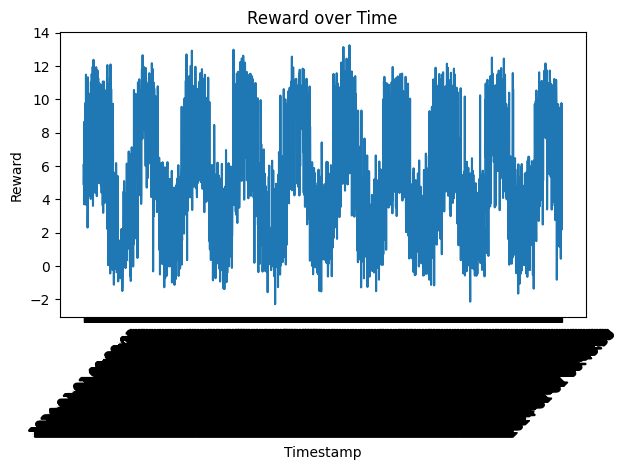

In [18]:
import matplotlib.pyplot as plt

print(df[action_feature].value_counts())
print(df[reward_feature].describe())

plt.plot(df['timestamp'], df[reward_feature])
plt.title('Reward over Time')
plt.xlabel('Timestamp')
plt.ylabel('Reward')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Preparing Training Data

In [19]:
states = [t[0] for t in transitions]
actions_encoded = [t[1] for t in transitions]
rewards = [t[2] for t in transitions]
next_states = [t[3] for t in transitions]

import numpy as np
states = np.stack(states)
actions_encoded = np.array(actions_encoded)
rewards = np.array(rewards)
next_states = np.stack(next_states)

print("States shape:", states.shape)
print("Actions shape:", actions_encoded.shape)
print("Rewards shape:", rewards.shape)
print("Next states shape:", next_states.shape)


States shape: (2999, 10)
Actions shape: (2999,)
Rewards shape: (2999,)
Next states shape: (2999, 10)


In [20]:
# This step reshapes transitions for RL libraries like Stable Baselines/d3rlpy
X_states = np.stack([t[0] for t in transitions])      # shape: (n, state_dim)
X_next_states = np.stack([t[3] for t in transitions]) # shape: (n, state_dim)
y_actions = np.array([t[1] for t in transitions])     # shape: (n,)
y_rewards = np.array([t[2] for t in transitions])     # shape: (n,)


# Preparing for Training Data for Deep RL

In [21]:
import torch
import torch.nn as nn

class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x):
        return self.net(x)

state_dim = X_states.shape[1]
action_dim = len(np.unique(y_actions))
policy_net = PolicyNetwork(state_dim, action_dim)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#  Defining Neural Network Policy

In [22]:
import torch.optim as optim

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

epochs = 20
batch_size = 64

X_states_tensor = torch.tensor(X_states, dtype=torch.float32)
y_actions_tensor = torch.tensor(y_actions, dtype=torch.long)

for epoch in range(epochs):
    idx = np.random.permutation(len(X_states))
    for start in range(0, len(X_states), batch_size):
        end = start + batch_size
        batch_idx = idx[start:end]
        states_batch = X_states_tensor[batch_idx]
        actions_batch = y_actions_tensor[batch_idx]

        logits = policy_net(states_batch)
        loss = loss_fn(logits, actions_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f}")


Epoch 1/20 | Loss: 1.5960
Epoch 2/20 | Loss: 1.7183
Epoch 3/20 | Loss: 1.7026


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 4/20 | Loss: 1.7186
Epoch 5/20 | Loss: 1.6284
Epoch 6/20 | Loss: 1.9327
Epoch 7/20 | Loss: 1.6183
Epoch 8/20 | Loss: 1.6110
Epoch 9/20 | Loss: 1.6673
Epoch 10/20 | Loss: 1.6437
Epoch 11/20 | Loss: 1.6282
Epoch 12/20 | Loss: 1.6379
Epoch 13/20 | Loss: 1.5866
Epoch 14/20 | Loss: 1.5912
Epoch 15/20 | Loss: 1.5914
Epoch 16/20 | Loss: 1.6231
Epoch 17/20 | Loss: 1.6582
Epoch 18/20 | Loss: 1.7483
Epoch 19/20 | Loss: 1.6403
Epoch 20/20 | Loss: 1.6463


# Implementing DQN Training Loop

In [23]:
# Load and process test set the same way
sensor_test = pd.read_csv("sensor_readings_test.csv")
system_test = pd.read_csv("system_states_test.csv")
actions_test = pd.read_csv("action_logs_test.csv")
rewards_test = pd.read_csv("reward_signals_test.csv")

test_df = sensor_test.merge(system_test, on="timestamp").merge(actions_test, on="timestamp").merge(rewards_test, on="timestamp")
cat_cols_test = test_df.select_dtypes(include=['object']).columns.drop('timestamp')
for col in cat_cols_test:
    if col in encoders:
        test_df[col] = encoders[col].transform(test_df[col])
test_state_features = [col for col in test_df.columns if col not in ['timestamp', 'action_taken', 'reward']]
X_test = test_df[test_state_features].values.astype(float)
y_true_actions = test_df['action_taken'].values

# Predict actions with your trained policy
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
policy_net.eval()
with torch.no_grad():
    logits = policy_net(X_test_tensor)
    y_pred_actions = logits.argmax(dim=1).numpy()

# Evaluate policy accuracy
accuracy = np.mean(y_pred_actions == y_true_actions)
print("Test Policy Accuracy:", accuracy)


Test Policy Accuracy: 0.216


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Evaluation on Test Set

In [24]:
# Calculate total or average reward for RL agent vs. original actions (if ground-truth available)
y_test_rewards = test_df['reward'].values
agent_total_reward = np.sum(y_test_rewards[y_pred_actions == y_true_actions])
baseline_total_reward = np.sum(y_test_rewards)
print(f"RL Agent Matched Reward: {agent_total_reward} / Baseline Reward: {baseline_total_reward}")


RL Agent Matched Reward: 641.5411470757165 / Baseline Reward: 3076.3282866279906


# Hyperparameter Tuning

In [25]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),  # Increased layer size
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

optimizer = optim.Adam(policy_net.parameters(), lr=5e-4)


# Confusion Matrix

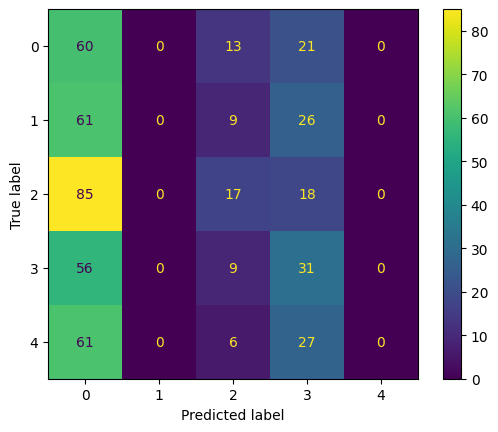

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true_actions, y_pred_actions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


# State-Action Distribution

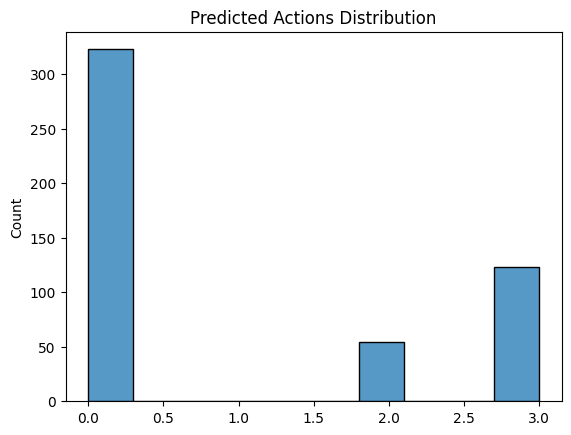

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [27]:
import seaborn as sns
sns.histplot(y_pred_actions)
plt.title("Predicted Actions Distribution")
plt.show()


# Reusability: Functions

In [29]:
def preprocess_data(sensor_path, system_path, actions_path, rewards_path, encoders=None):
    sensor = pd.read_csv(sensor_path)
    system = pd.read_csv(system_path)
    actions = pd.read_csv(actions_path)
    rewards = pd.read_csv(rewards_path)
    df = sensor.merge(system, on="timestamp").merge(actions, on="timestamp").merge(rewards, on="timestamp")
    df = df.sort_values('timestamp').reset_index(drop=True)
    cat_cols = df.select_dtypes(include=['object']).columns.drop('timestamp')
    encoders = encoders or {}
    for col in cat_cols:
        if col not in encoders:
            encoders[col] = LabelEncoder().fit(df[col])
        df[col] = encoders[col].transform(df[col])
    return df, encoders


In [30]:
train_df, encoders = preprocess_data("sensor_readings_train.csv", "system_states_train.csv", "action_logs_train.csv", "reward_signals_train.csv")
test_df, _ = preprocess_data("sensor_readings_test.csv", "system_states_test.csv", "action_logs_test.csv", "reward_signals_test.csv", encoders)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
